In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

In [3]:
df = pd.read_csv(r"C:\Users\ryana\Downloads\DataSet\TSLA.csv")

In [4]:
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800000,5.000000,3.508000,4.778000,4.778000,93831500
1,2010-06-30,5.158000,6.084000,4.660000,4.766000,4.766000,85935500
2,2010-07-01,5.000000,5.184000,4.054000,4.392000,4.392000,41094000
3,2010-07-02,4.600000,4.620000,3.742000,3.840000,3.840000,25699000
4,2010-07-06,4.000000,4.000000,3.166000,3.222000,3.222000,34334500
...,...,...,...,...,...,...,...
2951,2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500
2952,2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200
2953,2022-03-22,930.000000,997.859985,921.750000,993.979980,993.979980,35289500
2954,2022-03-23,979.940002,1040.699951,976.400024,999.109985,999.109985,40225400


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2956 non-null   object 
 1   Open       2956 non-null   float64
 2   High       2956 non-null   float64
 3   Low        2956 non-null   float64
 4   Close      2956 non-null   float64
 5   Adj Close  2956 non-null   float64
 6   Volume     2956 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 161.8+ KB


In [6]:
### Covert to index and datetime
df = df.set_index('Date') # change column datetime to index 
df.index = pd.to_datetime(df.index) # change data type to datetime

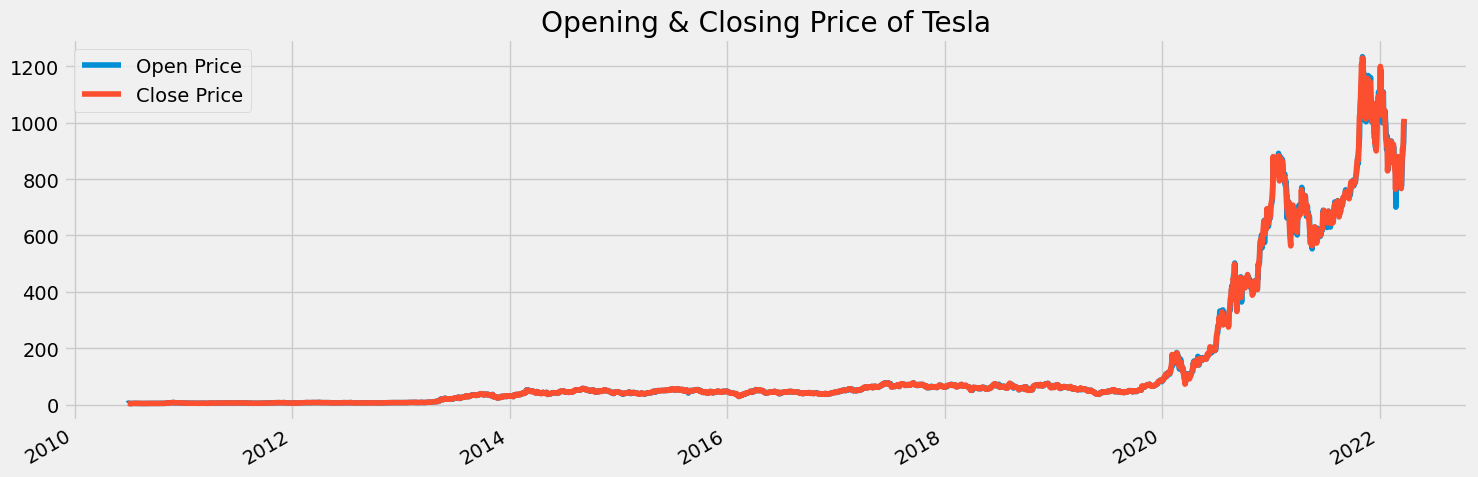

In [7]:
plt.figure(figsize=(15, 5))
df['Open'].plot()
df['Close'].plot()
plt.ylabel(None)
plt.xlabel(None)
plt.title("Opening & Closing Price of Tesla")
plt.legend(['Open Price', 'Close Price'])
plt.tight_layout()
plt.show()

In [8]:
df.sample()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2019-11-01,63.264,63.296001,61.959999,62.661999,62.661999,31919500


### Feature Engginering

#### Lag Features

In [9]:
for i in range(1,6):
    df[f'lag_close_{i}'] = df['Close'].shift(i)

#### Moving Averages (SMA)

In [10]:
df['sma_7'] = df['Close'].rolling(window=7).mean()
df['sma_21'] = df['Close'].rolling(window=21).mean()

#### Exponential Moving Average (EMA)

In [11]:
df['ema_7'] = df['Close'].ewm(span=7, adjust=False).mean()
df['ema_21'] = df['Close'].ewm(span=21, adjust=False).mean()

#### Return & Volatility

In [12]:
df['return_1d'] = df['Close'].pct_change()
df['volatility_7d'] = df['return_1d'].rolling(window=7).std()

#### Volume Moving Average

In [13]:
df['vol_ma_7'] = df['Volume'].rolling(window=7).mean()

In [14]:
df.sample(5)

,Open,High,Low,Close,Adj Close,Volume,lag_close_1,lag_close_2,lag_close_3,lag_close_4,lag_close_5,sma_7,sma_21,ema_7,ema_21,return_1d,volatility_7d,vol_ma_7
Date,,,,,,,,,,,,,,,,,,
2019-11-20,72.000000,72.239998,69.914001,70.444000,70.444000,33625500,71.903999,69.998001,70.433998,69.870003,69.222000,70.265429,65.790381,69.917618,65.385227,-0.020305,0.016310,3.278836e+07
2016-07-29,46.139999,47.056000,46.048000,46.958000,46.958000,15354000,46.122002,45.698002,45.902000,46.001999,44.453999,45.605143,44.570095,45.873105,44.776104,0.018126,0.021521,1.664857e+07
2021-07-02,678.979980,700.000000,673.260010,678.900024,678.900024,27054500,677.919983,679.700012,680.760010,688.719971,671.869995,679.670000,635.580479,672.455556,647.996065,0.001446,0.018232,2.601464e+07
2010-09-24,3.990000,4.038000,3.930000,4.020000,4.020000,2894500,3.912000,3.974000,4.154000,4.212000,4.046000,4.072286,4.095524,4.055760,4.070823,0.027607,0.034413,5.597429e+06
2018-03-19,63.299999,64.150002,61.933998,62.712002,62.712002,37421500,64.269997,65.120003,65.325996,68.367996,69.101997,65.761713,67.084857,65.096412,66.331734,-0.024241,0.030939,3.419314e+07


In [15]:
# Drop baris yang memiliki NaN akibat rolling/shift
df.dropna(inplace=True)

In [16]:
# Reset index setelah drop
df.reset_index(drop=True, inplace=True)

In [17]:
df.shape

(2936, 18)

In [18]:
df.sample(3)

,Open,High,Low,Close,Adj Close,Volume,lag_close_1,lag_close_2,lag_close_3,lag_close_4,lag_close_5,sma_7,sma_21,ema_7,ema_21,return_1d,volatility_7d,vol_ma_7
2612,574.369995,627.750000,566.340027,627.070007,627.070007,67083200,604.479980,649.880005,641.760010,599.039978,593.380005,612.061427,535.066188,610.843255,553.152387,0.037371,0.047215,5.409687e+07
873,33.689999,34.445999,32.419998,32.826000,32.826000,102328000,32.254002,27.868000,29.143999,29.506001,30.256001,30.246572,29.924572,30.688373,29.857881,0.017734,0.065855,5.601007e+07
2364,75.797997,77.099998,75.180000,75.797997,75.797997,42484000,76.300003,71.678001,71.935997,70.540001,69.767998,71.989428,69.200762,72.590683,69.341998,-0.006579,0.023879,4.696786e+07


### Train/Test Split

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
# Select features will be used
features = [
    'lag_close_1', 'lag_close_2', 'lag_close_3', 'lag_close_4', 'lag_close_5',
    'sma_7', 'sma_21', 'ema_7', 'ema_21',
    'return_1d', 'volatility_7d', 'vol_ma_7'
]
target = 'Close'

In [21]:
# split X & y
X = df[features]
y = df[target]

In [22]:
# Time-based split
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

### Modelling - Random Forest

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [24]:
# Inisialisasi dan training model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [25]:
print(f'RMSE: {rmse:.3f}')
print(f'MAE : {mae:.3f}')
print(f'R2 Score: {r2:.4f}')

RMSE: 571.879
MAE : 477.266
R2 Score: -2.2880


### 📊 Visualisasi Prediksi vs Aktual

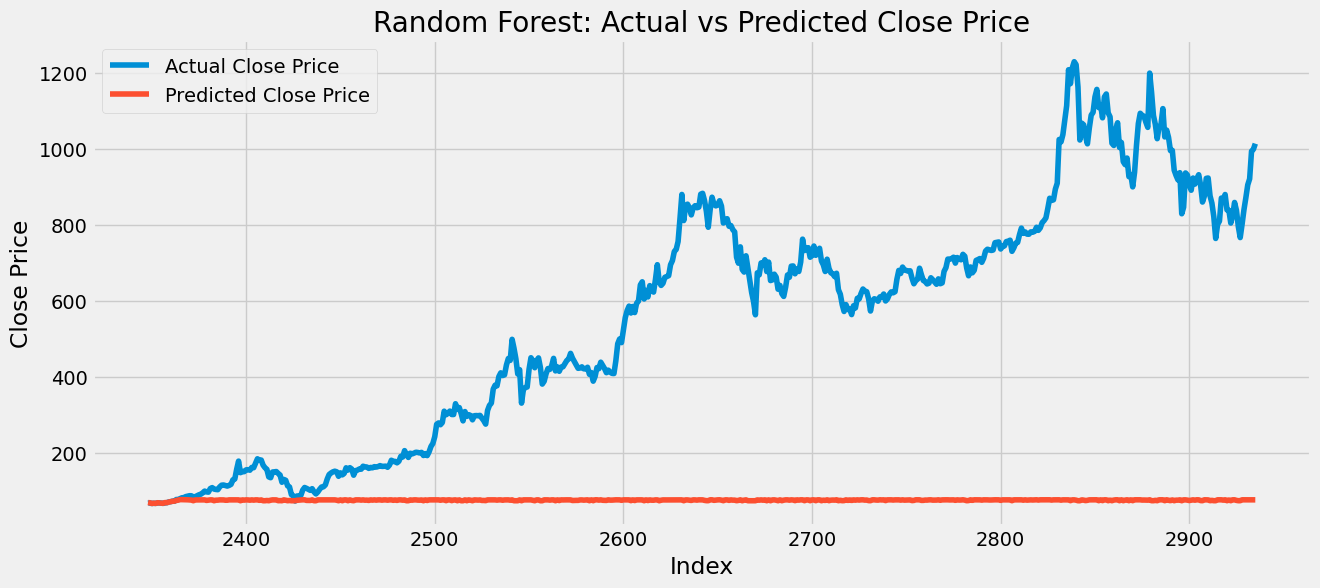

In [26]:
plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test.values, label='Actual Close Price')
plt.plot(y_test.index, y_pred, label='Predicted Close Price')
plt.legend()
plt.title('Random Forest: Actual vs Predicted Close Price')
plt.xlabel('Index')
plt.ylabel('Close Price')
plt.show()

### XGBoost Model

In [27]:
from xgboost import XGBRegressor

In [28]:
#Inisialisasi model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

# Latih model
xgb_model.fit(X_train, y_train)

# Prediksi
y_pred_xgb = xgb_model.predict(X_test)

# Evaluasi
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

In [29]:
print(f'[XGBoost] RMSE: {rmse_xgb:.3f}')
print(f'[XGBoost] MAE : {mae_xgb:.3f}')
print(f'[XGBoost] R² Score: {r2_xgb:.4f}')

[XGBoost] RMSE: 571.599
[XGBoost] MAE : 476.917
[XGBoost] R² Score: -2.2848


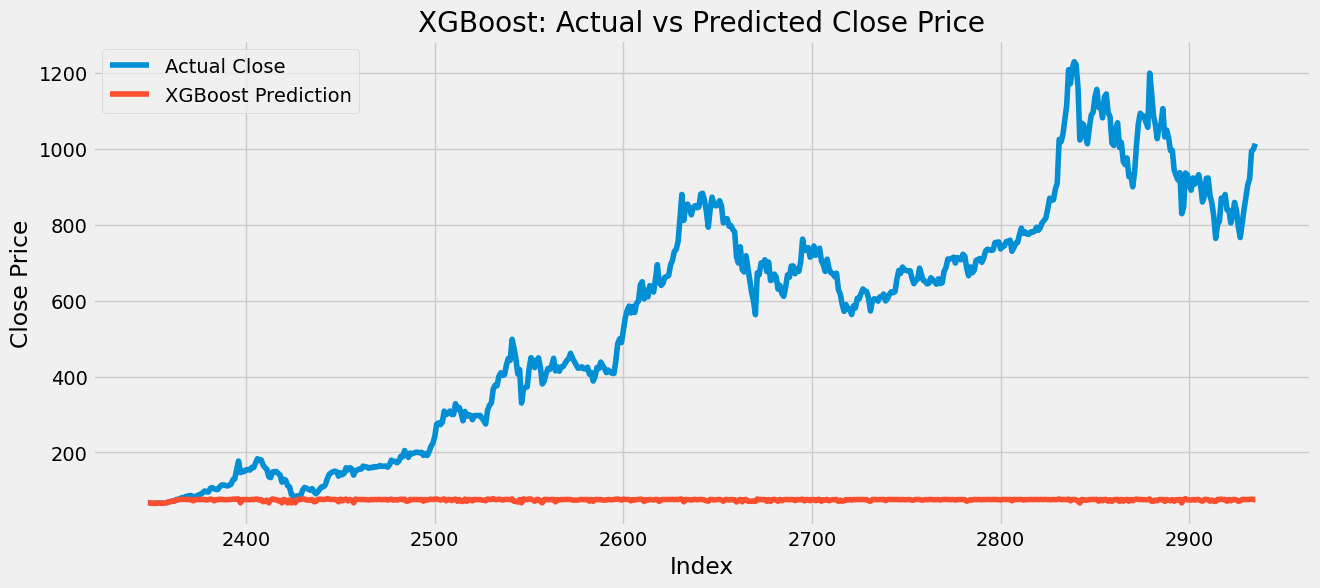

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test.values, label='Actual Close')
plt.plot(y_test.index, y_pred_xgb, label='XGBoost Prediction')
plt.title('XGBoost: Actual vs Predicted Close Price')
plt.xlabel('Index')
plt.ylabel('Close Price')
plt.legend()
plt.show()